In [1]:
# IMPORT NECESSARY LIBRARIES

import sys
import os
from pynwb import NWBHDF5IO as nwb

import nemos as nmo
import pynapple as nap
from nemos import _documentation_utils as doc_plots

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestClassifier

# import from src folder
import preprocessing
import window
import training

# summary of data
# there's 312 nwb files in total, 375 trials per recording (not entirely sure how important the 375 trials is)
# each of the nwb files have keys (index postion, threshold crossings, etc.) and are recorded into 27649 time bins (bin size 0.02s), and the are 96 channels
# a trial is likely a segment within a recording
'''
structure of the data:
each "timestamp" is a bin and it is 0.02 seconds, corresponds to a single datapoint

1. index position (index finger movement): single channel x 27000 timestamps 
2. index velocity: single channel x 27000 timestamps (derivative of the above)
3. mrs_position (middle ring pinky movement): single channel x 27000 timestamps
4. mrs_velocity: single channel x 27000 timestamps
5. spiking bandpower: 96 x 27000 timestamps (96 channels of recording)
6. threshold crossings: 96 x 27000 timestamps

session: one recording day
trial: one attempt at a finger movement
bin: one timestamp/signal/recording of 0.2 seconds
'''

E:\anaconda3\envs\neuro\Lib\site-packages\nemos\_documentation_utils\plotting.py:38: UserWarning: plotting functions contained within `_documentation_utils` are intended for nemos's documentation. Feel free to use them, but they will probably not work as intended with other datasets / in other contexts.
  warnings.warn(


In [2]:
# IMPORT RECORDINGS

# folder path to the monkey data
folder_path = "../data/dandi/001201/sub-Monkey-N/"

# append the path to the src folder
sys.path.append(os.path.abspath("../src"))

nwb_files = []

# os.walk finds all nwb files recursively
for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".nwb"):
            nwb_files.append(os.path.join(root, file))

print(f"Found {len(nwb_files)} NWB files.")

# Open the first file
file_path = nwb_files[0]
print("\nOpening:", file_path)

io = nwb(file_path, "r")
nwbfile = io.read()

Found 312 NWB files.

Opening: ../data/dandi/001201/sub-Monkey-N/sub-Monkey-N_ses-20200127_ecephys.nwb


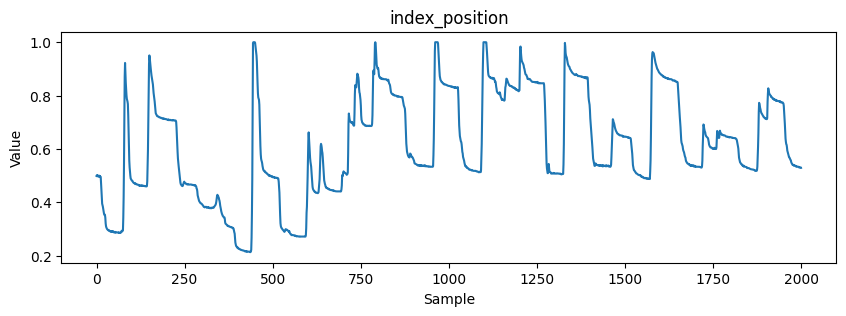

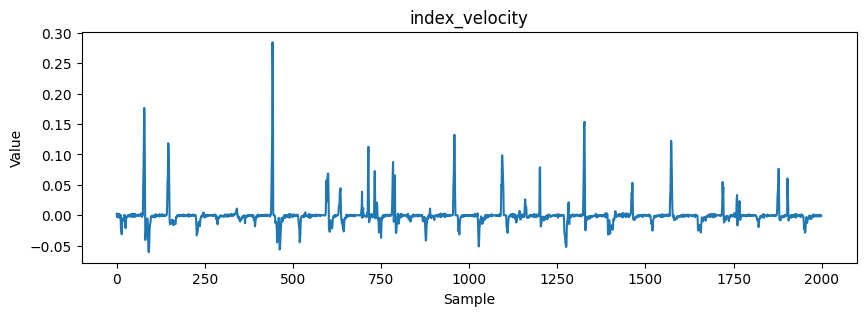

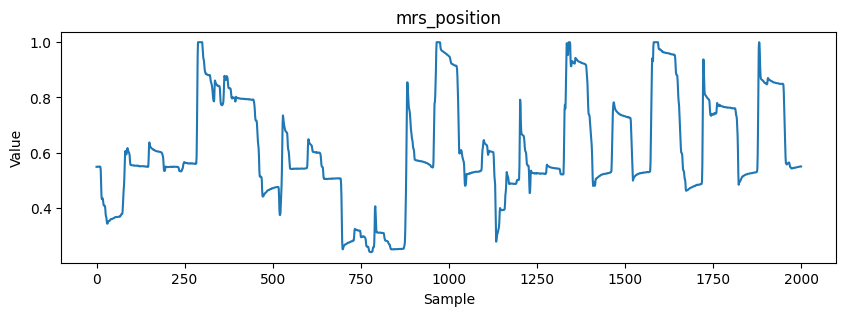

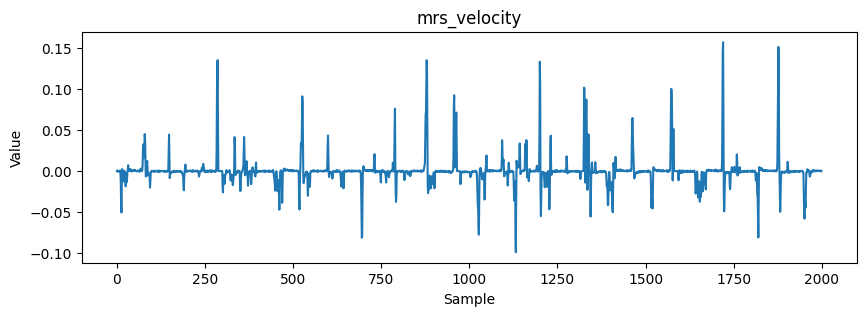

In [4]:
# visualizing 2000 timesteps of the single channel data

behavior_keys = ["index_position", "index_velocity", "mrs_position", "mrs_velocity"]

for key in behavior_keys:
    if key in nwbfile.analysis:
        obj = nwbfile.analysis[key]
        data = np.asarray(obj.data[:2000])

        plt.figure(figsize=(10, 3))
        if data.ndim == 1:
            plt.plot(data)
        else:
            plt.plot(data[:, 0])
        plt.title(key)
        plt.xlabel("Sample")
        plt.ylabel("Value")
        plt.show()

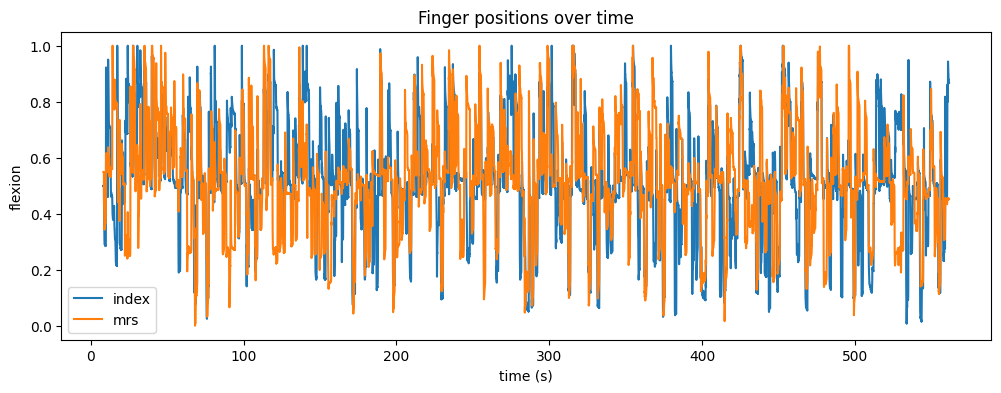

In [8]:
# visualizing index position versus middle finger flexion position; 27000 time bins x 0.02 seconds each = 540 seconds

# looking at the index position
index_pos = np.asarray(nwbfile.analysis["index_position"].data[:])
index_velocity = np.asarray(nwbfile.analysis["index_position"].data[:])

# looking at the middle, ring, pinky position
mrs_pos = np.asarray(nwbfile.analysis["mrs_position"].data[:])

# getting the timestamps
t = nwbfile.analysis["index_position"].timestamps[:]


# plotting everything
plt.figure(figsize=(12,4))
plt.plot(t, index_pos, label="index")
plt.plot(t, mrs_pos, label="mrs")
plt.xlabel("time (s)")
plt.ylabel("flexion")
plt.legend()
plt.title("Finger positions over time")
plt.show()

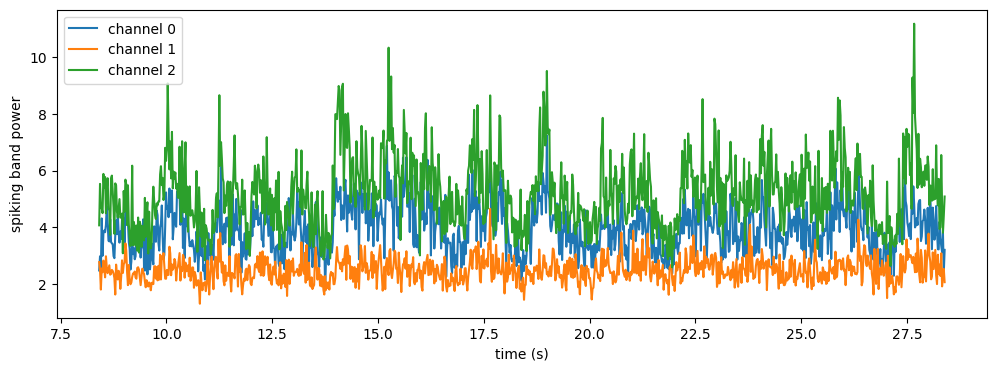

In [6]:
sbp = np.asarray(nwbfile.analysis["SpikingBandPower"].data[:])

plt.figure(figsize=(12,4))
plt.plot(t[:1000], sbp[:1000,0], label="channel 0")
plt.plot(t[:1000], sbp[:1000,1], label="channel 1")
plt.plot(t[:1000], sbp[:1000,2], label="channel 2")
plt.xlabel("time (s)")
plt.ylabel("spiking band power")
plt.legend()
plt.show()

In [ ]:
'''
============================================================================================================================================================
Everything below this point is actual preprocessing/analysis/training of models
============================================================================================================================================================
'''

In [9]:
# implement pre-processing pipeline on sbp

def preprocessing_pipeline(session_data):

    # get spiking band power
    sbp = np.asarray(session_data.analysis["SpikingBandPower"].data[:])

    # smooth sbp
    smoothed_sbp = preprocessing.smoothing(sbp)
    
    # normalize data across channels
    normalized_sbp = preprocessing.zscore_channels(smoothed_sbp)
    
    # perform dimensionality reduction
    reduced, pca_model = preprocessing.apply_pca(normalized_sbp)

    # get index position
    idx_pos = np.asarray(session_data.analysis["index_position"].data[:].squeeze())

    return sbp, smoothed_sbp, normalized_sbp, reduced, pca_model, idx_pos

In [14]:
def open_nwb_file(nwb_filepaths, number):

    # get the file path
    file_path = nwb_filepaths[number]
    
    io = nwb(file_path, "r")
    nwbfile = io.read()

    return nwbfile

In [28]:
'''
RIDGE REGRESSION with one session recording (our of 312).
Note: for now we only train models across trials (since they come from the same session) because neural non-stationarities affect data across sessions,
such as electrodes moving, etc.

Note to self: r2 value jumped from 0.14 ot 0.33 after we didn't reduce dimension
'''

# training data is spiking bandpower, and we predict index position with it
nwb_file = open_nwb_file(nwb_files, 0)
sbp, _, X, _, _, _ = preprocessing_pipeline(nwb_file)

# get index postion 
index_pos = np.asarray(
    nwb_file.analysis["index_position"].data[:]
)

y = index_pos.squeeze()

# 80-20 split of the training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ridge regression, fit the model too
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# predict on the test data
pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))

R2: 0.3342982075570834


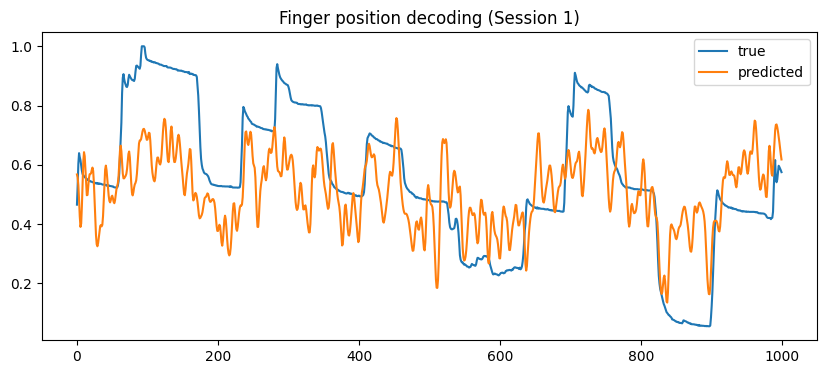

In [29]:
plt.figure(figsize=(10,4))
plt.plot(y_test[:1000], label="true")
plt.plot(pred[:1000], label="predicted")
plt.legend()
plt.title("Finger position decoding (Session 1)")
plt.show()

In [ ]:
'''
LONG SHORT TERM MEMORY (LSTM) across sessions. 

sbp, smoothed_sbp, normalized_sbp, reduced, pca_model, idx_pos
'''

from 

def build_multisession_dataset(
    nwb_files,
    session_indices,
    seq_len = 100,
    predict_ahead = 0,
):
    '''
    We want the LSTM to be able to generalize across sessions, so we build multisessions datasets.
    '''

    session_datasets = []

    for session_idx in session_indices:

        # load data and preprocess
        nwb_file = open_nwb_file(nwb_files, session_idx)
        _, _, X, _, _, y = preprocessing_pipeline(nwb_file)

        dataset = window.NeuralSequenceDataset(
            X, y, seq_len = seq_len, predict_ahead = predict_ahead
        )

        session_datasets.append
              
    